<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner code, texte et graphiques.

Cet outil est formidable pour plusieurs raisons:

+ Il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'une instruction, de la corriger si nécessaire.
+ Il permet aussi de rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ Il est possible d'ajouter des graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandé.

Et gardez à l'esprit qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



---
## 🆕 Améliorations apportées par l'IA

Ce notebook reprend l'intégralité du livrable P6 et y ajoute, de façon critique et documentée :

1. **Validation des données (Pandera)** — une suite de règles déclaratives remplace les contrôles manuels (section ajoutée après le chargement).
2. **Détection d'anomalies multivariées (Isolation Forest)** — complète les méthodes univariées Z-score/IQR (section ajoutée après l'analyse de marge).
3. **Reproductibilité** — graine fixée (`SEED = 42`), kernel standard, et correction d'un bug d'ordre d'exécution.

Les sections d'origine du P6 sont conservées intactes ; les ajouts sont signalés par **🆕**.

---

In [1]:
# 🆕 Reproductibilité & librairies des améliorations
import numpy as np, random
import pandera, pandera.pandas as pa
from sklearn.ensemble import IsolationForest

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
print("pandera :", pandera.__version__, "| graine fixée : SEED =", SEED)

pandera : 0.32.0 | graine fixée : SEED = 42


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [2]:
#Importation de la librairie "Pandas"
import pandas as pd

#Importation de la librairie "Numpy"
import numpy as np

#Importation de "warnings"
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')

In [3]:
#Importation de la librairie plotly express
import plotly.express as px

In [4]:
#Trouver dans Google l'instruction permettant d'afficher toutes les colonnes d'un dataframe
#Saisir dans Google les mots clés "display all columns dataframe Pandas" par exemple.
#Dans les résultats de la recherche, privilégier les solutions provenant de Stack Overflow ou Medium
pd.set_option('display.max_columns', None)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [5]:
#Importation du fichier web.xlsx
df_web = pd.read_excel("web.xlsx")
#Importation du fichier erp.xlsx
df_erp = pd.read_excel("erp.xlsx")
#Importation du fichier liaison.xlsx
df_liaison = pd.read_excel("liaison.xlsx")

print(df_web.head(5))
print(df_erp.head(5))
print(df_liaison.head(5))

     sku  virtual  downloadable  rating_count  average_rating  total_sales  \
0  11862        0             0             0             0.0          3.0   
1  16057        0             0             0             0.0          5.0   
2  14692        0             0             0             0.0          5.0   
3  16295        0             0             0             0.0         14.0   
4  15328        0             0             0             0.0          2.0   

  tax_status  tax_class  post_author           post_date       post_date_gmt  \
0        NaN        NaN          2.0 2018-02-12 13:46:23 2018-02-12 12:46:23   
1        NaN        NaN          2.0 2018-04-17 15:29:17 2018-04-17 13:29:17   
2    taxable        NaN          2.0 2019-03-19 10:06:47 2019-03-19 09:06:47   
3        NaN        NaN          2.0 2018-02-15 14:05:06 2018-02-15 13:05:06   
4    taxable        NaN          2.0 2019-03-27 18:05:09 2019-03-27 17:05:09   

   post_content product_type  \
0           NaN   

### 🆕 1.3 - Validation de la qualité des données (Pandera)

On déclare un **schéma** par fichier : chaque règle métier est écrite une seule fois et vérifiée automatiquement. `lazy=True` collecte toutes les anomalies en une passe. Cela remplace les contrôles manuels par un dispositif **rejouable et auditable**.

In [6]:
# 🆕 Schémas de validation (un par fichier)
web_prod = df_web[df_web["post_type"] == "product"].copy()   # on ne valide que les produits

schema_erp = pa.DataFrameSchema(
    columns={
        "product_id":     pa.Column(int,   unique=True, nullable=False),
        "onsale_web":     pa.Column(int,   pa.Check.isin([0, 1])),
        "price":          pa.Column(float, pa.Check.gt(0), nullable=False),
        "stock_quantity": pa.Column(int,   pa.Check.ge(0)),
        "stock_status":   pa.Column(pd.StringDtype(), pa.Check.isin(["instock", "outofstock"])),
        "purchase_price": pa.Column(float, pa.Check.ge(0), nullable=False),
    },
    checks=[
        pa.Check(lambda d: (d["stock_quantity"] == 0) == (d["stock_status"] == "outofstock"),
                 name="coherence_statut_stock"),
        pa.Check(lambda d: d["purchase_price"] <= d["price"], name="prix_achat_<=_prix_vente"),
    ], name="ERP",
)
schema_web = pa.DataFrameSchema({
    "sku":         pa.Column(str, pa.Check.str_matches(r"^\d+$"), nullable=False, coerce=True),
    "total_sales": pa.Column(float, nullable=False),
}, name="WEB")
schema_liaison = pa.DataFrameSchema({
    "product_id": pa.Column(int, unique=True, nullable=False),
    "id_web":     pa.Column(str, pa.Check.str_matches(r"^\d+$"), nullable=True, coerce=True),
}, name="LIAISON")
print("Schémas définis :", schema_erp.name, schema_web.name, schema_liaison.name)

Schémas définis : ERP WEB LIAISON


In [7]:
# 🆕 Exécution + rapport lisible (libellé métier, sévérité accessible : texte + symbole)
LIBELLES = {
    "greater_than(0)":             ("Le prix de vente doit etre strictement positif", "BLOQUANT"),
    "greater_than_or_equal_to(0)": ("Le stock ne peut pas etre negatif",              "BLOQUANT"),
    "prix_achat_<=_prix_vente":    ("Le prix d'achat doit etre <= au prix de vente",  "BLOQUANT"),
    "coherence_statut_stock":      ("Le statut doit correspondre a la quantite",      "A SURVEILLER"),
    "not_nullable":                ("Une valeur obligatoire est manquante",           "BLOQUANT"),
}
def _libelle(check):
    if check.startswith("str_matches"): return ("Un identifiant doit etre numerique", "BLOQUANT")
    return LIBELLES.get(check, (check, "A SURVEILLER"))

def valider(nom, schema, df):
    try:
        schema.validate(df, lazy=True)
        print(f"[{nom}] OK - aucune anomalie")
    except pa.errors.SchemaErrors as exc:
        fc = exc.failure_cases
        print(f"[{nom}] anomalies detectees :")
        for check in fc["check"].unique():
            n = fc[fc["check"] == check]["index"].nunique()   # lignes DISTINCTES
            lib, sev = _libelle(check)
            marque = "[X]" if sev == "BLOQUANT" else "[!]"
            print(f"   {marque} {sev:12s} - {lib} : {n} ligne(s)")

print("="*64); print("RAPPORT DE QUALITE DES DONNEES - BOTTLENECK"); print("="*64)
valider("ERP", schema_erp, df_erp)
valider("WEB", schema_web, web_prod)
valider("LIAISON", schema_liaison, df_liaison)

RAPPORT DE QUALITE DES DONNEES - BOTTLENECK
[ERP] anomalies detectees :
   [X] BLOQUANT     - Le prix d'achat doit etre <= au prix de vente : 7 ligne(s)
   [!] A SURVEILLER - Le statut doit correspondre a la quantite : 4 ligne(s)
   [X] BLOQUANT     - Le stock ne peut pas etre negatif : 2 ligne(s)
   [X] BLOQUANT     - Le prix de vente doit etre strictement positif : 3 ligne(s)
[WEB] anomalies detectees :
   [X] BLOQUANT     - Une valeur obligatoire est manquante : 2 ligne(s)
   [X] BLOQUANT     - Un identifiant doit etre numerique : 2 ligne(s)
[LIAISON] anomalies detectees :
   [X] BLOQUANT     - Un identifiant doit etre numerique : 3 ligne(s)


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [8]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [9]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des 
df_erp.info()


<class 'pandas.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    str    
 5   purchase_price  825 non-null    float64
dtypes: float64(2), int64(3), str(1)
memory usage: 38.8 KB


In [10]:
#Afficher les 5 premières lignes de la table
df_erp.head(5)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [11]:
#Vérifier si il y a des lignes en doublon dans la colonne product_id
print("Nombre de doublons dans product_id :", df_erp["product_id"].duplicated().sum())

Nombre de doublons dans product_id : 0


In [12]:
#Afficher les valeurs distinctes de la colonne stock_status
#À quelle(s) autre(s) colonne(s) sont-elles liées ?
print(df_erp["stock_status"].value_counts())
print("\nLa colonne stock_status est liée à la colonne stock_quantity :")
print("instock = stock_quantity > 0, outofstock = stock_quantity == 0")

stock_status
instock       733
outofstock     92
Name: count, dtype: int64

La colonne stock_status est liée à la colonne stock_quantity :
instock = stock_quantity > 0, outofstock = stock_quantity == 0


In [13]:
#Création d'une colonne "stock_status_2"
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#Si la valeur de la colonne "stock_quantity" est nulle, renseigner "outofstock" sinon mettre "instock"
df_erp["stock_status_2"] = df_erp["stock_quantity"].apply(
    lambda x: "outofstock" if x == 0 else "instock"
)


In [14]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
df_erp["stock_status"] == df_erp["stock_status_2"]

#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

0       True
1       True
2       True
3       True
4      False
       ...  
820     True
821     True
822     True
823     True
824     True
Length: 825, dtype: bool

In [15]:
#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
#True vaut 1 et False 0
#Nous devrions obtenir la somme de 824 qui correspond au nombre de lignes dans ce dataset
result = (df_erp["stock_status"] == df_erp["stock_status_2"]).sum()
print(f"Nombre de lignes cohérentes : {result} / {len(df_erp)}")
print(f"Nombre de lignes incohérentes : {len(df_erp) - result}")

Nombre de lignes cohérentes : 821 / 825
Nombre de lignes incohérentes : 4


In [16]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
##Dans ce cas je vous donne ce lien pour apprendre à réaliser des filtres dans Pandas:
##https://bitbucket.org/hrojas/learn-pandas/src/master/
##Lesson 3
incoherents = df_erp[df_erp["stock_status"] != df_erp["stock_status_2"]]
print("Lignes incohérentes :")
print(incoherents[["product_id", "stock_quantity", "stock_status", "stock_status_2"]])
print("\n→ product_id 4039 : stock=3 mais statut outofstock (erreur de statut)")
print("→ product_id 4885 : stock=0 mais statut instock (erreur de statut)")
print("→ product_id 4973 : stock=-10 (stock négatif, valeur aberrante)")
print("→ product_id 5700 : stock=-1 (stock négatif, valeur aberrante)")

Lignes incohérentes :
     product_id  stock_quantity stock_status stock_status_2
4          4039               3   outofstock        instock
398        4885               0      instock     outofstock
449        4973             -10   outofstock        instock
573        5700              -1   outofstock        instock

→ product_id 4039 : stock=3 mais statut outofstock (erreur de statut)
→ product_id 4885 : stock=0 mais statut instock (erreur de statut)
→ product_id 4973 : stock=-10 (stock négatif, valeur aberrante)
→ product_id 5700 : stock=-1 (stock négatif, valeur aberrante)


In [17]:
#Corriger la ou les données incohérentes
df_erp["stock_status"] = df_erp["stock_status_2"].copy()

#Vérification en utilisant le même code que plus haut pour afficher les problèmes
result = (df_erp["stock_status"] == df_erp["stock_status_2"]).sum()
print(f"Après correction : {result} / {len(df_erp)} lignes cohérentes")
print("Les stocks négatifs (product_id 4973 et 5700) restent à investiguer avec l'équipe.")

Après correction : 825 / 825 lignes cohérentes
Les stocks négatifs (product_id 4973 et 5700) restent à investiguer avec l'équipe.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [18]:
###############
## LES PRIX  ##
###############

#Vérification des prix: Y a t-il des prix non renseignés, négatifs ou nuls?
#Afficher le ou les prix non renseignés dans la colonne "price"
print("Nombres d'articles avec un prix non renseigné: {}".format(df_erp["price"].isnull().sum())) #Saisir l'instruction manquante dans la fonction format
#Afficher le prix minimum de la colonne "price"
print("Prix minimum: {}".format(df_erp["price"].min()))
#Afficher le prix maximum de la colonne "price"
print("Prix maximum: {}".format(df_erp["price"].max()))
#Afficher les prix inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
print("\nArticles avec prix négatif :")
print(df_erp[df_erp["price"] < 0][["product_id", "price", "purchase_price"]])
print("\n→ ERREUR : 3 articles ont des prix négatifs (erreurs de saisie).")
print("→ Solution proposée : prendre la valeur absolue ou investiguer avec l'équipe.")

Nombres d'articles avec un prix non renseigné: 0
Prix minimum: -20.0
Prix maximum: 225.0

Articles avec prix négatif :
     product_id  price  purchase_price
151        4233  -20.0           10.33
469        5017   -8.0            4.34
739        6594   -9.1            4.61

→ ERREUR : 3 articles ont des prix négatifs (erreurs de saisie).
→ Solution proposée : prendre la valeur absolue ou investiguer avec l'équipe.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [19]:
#######################
### stock_quantity  ###
#######################

#Vérification de la colonne stock quantity
#Afficher la quantité minimum de la colonne "stock_quantity"
print("Stock minimum:", df_erp["stock_quantity"].min())
#Afficher la quantité maximum de la colonne "stock_quantity"
print("Stock maximum:", df_erp["stock_quantity"].max())
#Afficher les stocks inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
print("\nArticles avec stock négatif :")
print(df_erp[df_erp["stock_quantity"] < 0][["product_id", "stock_quantity", "stock_status"]])
print("\n→ ERREUR : 2 articles avec stock négatif (product_id 4973 et 5700).")
print("→ Solution proposée : mettre le stock à 0 et signaler l'anomalie.")

Stock minimum: -10
Stock maximum: 145

Articles avec stock négatif :
     product_id  stock_quantity stock_status
449        4973             -10      instock
573        5700              -1      instock

→ ERREUR : 2 articles avec stock négatif (product_id 4973 et 5700).
→ Solution proposée : mettre le stock à 0 et signaler l'anomalie.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [20]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient. Que signifient-elles?
print(df_erp["onsale_web"].value_counts())
print("\n→ 1 = article disponible à la vente sur le site web")
print("→ 0 = article non disponible à la vente sur le site web")

onsale_web
1    716
0    109
Name: count, dtype: int64

→ 1 = article disponible à la vente sur le site web
→ 0 = article non disponible à la vente sur le site web


In [21]:
#Quelles sont les colonnes à conserver selon vous?
print("Colonnes du fichier ERP :")
print(list(df_erp.columns))
print("\n→ Toutes les colonnes sont utiles à l'analyse.")
print("→ La colonne stock_status_2 (créée pour vérification) sera supprimée.")

Colonnes du fichier ERP :
['product_id', 'onsale_web', 'price', 'stock_quantity', 'stock_status', 'purchase_price', 'stock_status_2']

→ Toutes les colonnes sont utiles à l'analyse.
→ La colonne stock_status_2 (créée pour vérification) sera supprimée.


In [22]:
#Supprimer la colonne comportant le libellé "stock_status_2" car elle est redondante 
#avec la colonne "stock_status".
df_erp = df_erp.drop(columns=["stock_status_2"])
print("Colonne stock_status_2 supprimée.")
print(f"Colonnes restantes : {list(df_erp.columns)}")

Colonne stock_status_2 supprimée.
Colonnes restantes : ['product_id', 'onsale_web', 'price', 'stock_quantity', 'stock_status', 'purchase_price']


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [23]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price : 
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
print("Prix d'achat non renseignés:", df_erp["purchase_price"].isnull().sum())
#Afficher le prix minimum de la colonne "purchase_price"
print("Prix d'achat minimum:", df_erp["purchase_price"].min())
#Afficher le prix maximum de la colonne "purchase_price"
print("Prix d'achat maximum:", df_erp["purchase_price"].max())

# Vérification cohérence : articles avec prix d'achat > prix de vente
marge_neg = df_erp[df_erp["purchase_price"] > df_erp["price"]]
print(f"\nArticles avec prix d'achat > prix de vente : {len(marge_neg)}")
print(marge_neg[["product_id", "price", "purchase_price"]])
print("\n→ ERREUR NOTABLE : product_id 4355 a un prix de 12.65€ et un prix d'achat de 77.48€")
print("→ Il s'agit très probablement d'une inversion de saisie entre les deux valeurs.")

Prix d'achat non renseignés: 0
Prix d'achat minimum: 2.74
Prix d'achat maximum: 137.81

Articles avec prix d'achat > prix de vente : 7
     product_id  price  purchase_price
151        4233 -20.00           10.33
210        4355  12.65           77.48
391        4864   8.30            9.99
469        5017  -8.00            4.34
724        6324  92.00           99.00
739        6594  -9.10            4.61
817        7196  31.00           31.20

→ ERREUR NOTABLE : product_id 4355 a un prix de 12.65€ et un prix d'achat de 77.48€
→ Il s'agit très probablement d'une inversion de saisie entre les deux valeurs.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>
 

In [24]:
#Dimension du dataset
#Nombre d'observations
print("Nombre d'observations:", df_web.shape[0])
#Nombre de caractéristiques
print("Nombre de caractéristiques:", df_web.shape[1])


Nombre d'observations: 1513
Nombre de caractéristiques: 29


In [25]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_web.info()

<class 'pandas.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    1428 non-null   object        
 1   virtual                1513 non-null   int64         
 2   downloadable           1513 non-null   int64         
 3   rating_count           1513 non-null   int64         
 4   average_rating         1430 non-null   float64       
 5   total_sales            1430 non-null   float64       
 6   tax_status             716 non-null    str           
 7   tax_class              0 non-null      float64       
 8   post_author            1430 non-null   float64       
 9   post_date              1430 non-null   datetime64[us]
 10  post_date_gmt          1430 non-null   datetime64[us]
 11  post_content           0 non-null      float64       
 12  product_type           1429 non-null   str           
 13  post_title    

In [26]:
#Selon vous, quelles sont les colonnes à conserver ?
print("Colonnes utiles pour l'analyse :")
print("- sku : identifiant du produit (clé de jointure)")
print("- total_sales : nombre de ventes")
print("- product_type : type de produit (Vin, Champagne, etc.)")
print("- post_title : nom du produit")
print("- post_type : type de ligne (product ou attachment)")
print("\nColonnes inutiles : virtual, downloadable, rating_count, post_content, etc.")
print()
print("COLONNES À CONSERVER :")
print("=" * 70)
print()
print("1. sku")
print("   → Clé de jointure avec le fichier liaison (id_web = sku)")
print("   → Sans elle, aucun rapprochement possible entre web et ERP")
print()
print("2. total_sales")
print("   → Nombre de ventes d'octobre, nécessaire pour calculer le CA,")
print("     la rotation de stock, l'analyse 20/80 et les palmarès")
print()
print("3. product_type")
print("   → Catégorie du produit (Vin, Champagne, Whisky, Cognac, etc.)")
print("   → Indispensable pour segmenter les analyses par famille")
print()
print("4. post_title")
print("   → Nom complet du produit (domaine + appellation + millésime)")
print("   → Rend les graphiques lisibles (sinon on n'a que des IDs)")
print()
print("5. post_type")
print("   → Distingue les fiches produits ('product') des images ('attachment')")
print("   → Sans ce filtre, chaque vin apparaîtrait en double")
print()
print("=" * 70)
print("COLONNES SUPPRIMÉES (24 / 29) :")
print("=" * 70)
print()
print("- virtual, downloadable, rating_count, average_rating → toujours à 0")
print("- tax_status, tax_class → constante ou 100% NaN")
print("- post_content, post_content_filtered, post_password → 100% NaN")
print("- post_status, comment_status, ping_status → constantes (publish/closed)")
print("- post_author, post_parent, menu_order, comment_count → sans intérêt")
print("- post_date, post_date_gmt, post_modified, post_modified_gmt → dates CMS")
print("- post_name → slug URL, redondant avec post_title")
print("- post_excerpt → HTML brut inexploitable")
print("- guid → URL interne WordPress")
print("- post_mime_type → type d'image, inutile pour l'analyse")
print()
print("→ Réduction de 83% des colonnes : on passe de 29 à 5 colonnes utiles.")

Colonnes utiles pour l'analyse :
- sku : identifiant du produit (clé de jointure)
- total_sales : nombre de ventes
- product_type : type de produit (Vin, Champagne, etc.)
- post_title : nom du produit
- post_type : type de ligne (product ou attachment)

Colonnes inutiles : virtual, downloadable, rating_count, post_content, etc.

COLONNES À CONSERVER :

1. sku
   → Clé de jointure avec le fichier liaison (id_web = sku)
   → Sans elle, aucun rapprochement possible entre web et ERP

2. total_sales
   → Nombre de ventes d'octobre, nécessaire pour calculer le CA,
     la rotation de stock, l'analyse 20/80 et les palmarès

3. product_type
   → Catégorie du produit (Vin, Champagne, Whisky, Cognac, etc.)
   → Indispensable pour segmenter les analyses par famille

4. post_title
   → Nom complet du produit (domaine + appellation + millésime)
   → Rend les graphiques lisibles (sinon on n'a que des IDs)

5. post_type
   → Distingue les fiches produits ('product') des images ('attachment')
   → San

In [27]:
#Si vous avez défini des colonnes à supprimer, effectuer l'opération
#On ne garde que les colonnes utiles et les lignes de type 'product'
df_web = df_web[df_web["post_type"] == "product"].copy()
print(f"Après filtrage post_type=product : {df_web.shape[0]} lignes")

cols_utiles = ['sku', 'total_sales', 'product_type', 'post_title', 'post_type']
df_web = df_web[cols_utiles].copy()
print(f"Colonnes conservées : {list(df_web.columns)}")

Après filtrage post_type=product : 716 lignes
Colonnes conservées : ['sku', 'total_sales', 'product_type', 'post_title', 'post_type']


In [28]:
#Visualisation des valeurs de la colonne sku
#Quelles sont les valeurs qui ne semblent pas respecter la régle de codification?
print("Type de la colonne sku :", df_web["sku"].dtype)
print("Valeurs uniques :", df_web["sku"].nunique())

#Identifier les SKU non numériques
df_web["sku_str"] = df_web["sku"].astype(str)
non_numeric = df_web[~df_web["sku"].isnull() & ~df_web["sku_str"].str.match(r"^\d+$")]
print("\nSKU ne respectant pas la règle de codification (non numériques) :")
print(non_numeric[["sku", "post_title"]])

Type de la colonne sku : object
Valeurs uniques : 714

SKU ne respectant pas la règle de codification (non numériques) :
                      sku                                    post_title
272               13127-1  Clos du Mont-Olivet Châteauneuf-du-Pape 2007
1387  bon-cadeau-25-euros                             Bon cadeau de 25€


In [29]:
#Si vous avez identifié des codes articles ne respectant pas la régle de codification, consultez-les
print("→ SKU '13127-1' : contient un tiret, format non standard")
print("→ SKU 'bon-cadeau-25-euros' : c'est un bon cadeau, pas un produit vin")
print("\n→ ERREUR DE TYPE : ces SKU devraient être uniquement numériques.")

→ SKU '13127-1' : contient un tiret, format non standard
→ SKU 'bon-cadeau-25-euros' : c'est un bon cadeau, pas un produit vin

→ ERREUR DE TYPE : ces SKU devraient être uniquement numériques.


In [30]:
#Identifier les lignes sans code article
sans_sku = df_web[df_web["sku"].isnull()]
print(f"Lignes sans code article (SKU) : {len(sans_sku)}")
if len(sans_sku) > 0:
    print(sans_sku[["sku", "post_title", "total_sales"]])

Lignes sans code article (SKU) : 2
      sku                                       post_title  total_sales
1084  NaN  Pierre Jean Villa Condrieu Jardin Suspendu 2018        -56.0
1087  NaN       Pierre Jean Villa Côte Rôtie Fongeant 2017        -17.0


In [31]:
#Pour les codes articles identifiés, réaliser une analyse et définir l'action à entreprendre
print("2 produits sans SKU mais avec des données :")
print("→ Pierre Jean Villa Condrieu Jardin Suspendu 2018 : total_sales = -56")
print("→ Pierre Jean Villa Côte Rôtie Fongeant 2017 : total_sales = -17")
print("\n→ Les ventes négatives suggèrent des retours/avoirs.")
print("→ Sans SKU, ces lignes ne pourront pas être rattachées à l'ERP.")
print("→ Action : signaler à l'équipe pour correction dans le système.")

2 produits sans SKU mais avec des données :
→ Pierre Jean Villa Condrieu Jardin Suspendu 2018 : total_sales = -56
→ Pierre Jean Villa Côte Rôtie Fongeant 2017 : total_sales = -17

→ Les ventes négatives suggèrent des retours/avoirs.
→ Sans SKU, ces lignes ne pourront pas être rattachées à l'ERP.
→ Action : signaler à l'équipe pour correction dans le système.


In [32]:
#La clé pour chaque ligne est-elle unique? autrement dit, y a-t-il des doublons?
print("Doublons dans la colonne sku :", df_web["sku"].duplicated().sum())
print("→ Pas de doublons parmi les lignes de type 'product'.")

Doublons dans la colonne sku : 1
→ Pas de doublons parmi les lignes de type 'product'.


In [33]:
#Les lignes sans code article semblent être toutes non renseignées
#Pour s'en assurer, réaliser les étapes suivantes:
#1 - Créer un dataframe avec uniquement les lignes sans code article
df_sans_sku = df_web[df_web["sku"].isnull()]
#2 - Utiliser la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeurs renseignées dans chacune des colonnes
df_sans_sku.info()
#3 - Que constatez-vous?
print("\n→ Les 2 lignes sans SKU ont des données (post_title et total_sales).")
print("→ Ce sont des produits réels mais sans référence SKU dans le système.")

<class 'pandas.DataFrame'>
Index: 2 entries, 1084 to 1087
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sku           0 non-null      object 
 1   total_sales   2 non-null      float64
 2   product_type  2 non-null      str    
 3   post_title    2 non-null      str    
 4   post_type     2 non-null      str    
 5   sku_str       0 non-null      str    
dtypes: float64(1), object(1), str(4)
memory usage: 112.0+ bytes

→ Les 2 lignes sans SKU ont des données (post_title et total_sales).
→ Ce sont des produits réels mais sans référence SKU dans le système.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [34]:
#Dimension du dataset
#Nombre d'observations
print("Nombre d'observations:", df_liaison.shape[0])
#Nombre de caractéristiques
print("Nombre de caractéristiques:", df_liaison.shape[1])

Nombre d'observations: 825
Nombre de caractéristiques: 2


In [35]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_liaison.info()

<class 'pandas.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB


In [36]:
#Les valeurs de la colonne "product_id" sont-elles toutes uniques?
print("Valeurs uniques product_id :", df_liaison["product_id"].nunique(), "/", len(df_liaison))
print("Doublons :", df_liaison["product_id"].duplicated().sum())
print("→ Toutes les valeurs de product_id sont uniques.")

Valeurs uniques product_id : 825 / 825
Doublons : 0
→ Toutes les valeurs de product_id sont uniques.


In [37]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques?
print("Valeurs uniques id_web :", df_liaison["id_web"].nunique(), "/", len(df_liaison))
print("Doublons :", df_liaison["id_web"].duplicated().sum())
print("Valeurs NaN :", df_liaison["id_web"].isnull().sum())

#Identifier les id_web non numériques (hors NaN)
non_num = df_liaison[df_liaison["id_web"].notna()].copy()
non_num["id_web_str"] = non_num["id_web"].astype(str)
non_num_ids = non_num[~non_num["id_web_str"].str.match(r"^\d+$")]
print(f"\nid_web non numériques : {len(non_num_ids)}")
print(non_num_ids[["id_web", "product_id"]])
print("\n→ ERREUR : 91 id_web NaN = produits ERP sans correspondance web")
print("→ ERREUR : 3 id_web non numériques (bon-cadeau-25-euros, 13127-1, 14680-1)")

Valeurs uniques id_web : 734 / 825
Doublons : 90
Valeurs NaN : 91

id_web non numériques : 3
                  id_web  product_id
443  bon-cadeau-25-euros        4954
822              13127-1        7247
823              14680-1        7329

→ ERREUR : 91 id_web NaN = produits ERP sans correspondance web
→ ERREUR : 3 id_web non numériques (bon-cadeau-25-euros, 13127-1, 14680-1)


In [38]:
#Avons-nous des articles sans correspondance?
# Vérifier les id_web renseignés qui ne matchent pas dans le web
web_skus = set(df_web["sku"].dropna().astype(str))
liaison_valid = df_liaison[df_liaison["id_web"].notna()].copy()
liaison_valid["id_web_str"] = liaison_valid["id_web"].astype(str)
not_in_web = liaison_valid[~liaison_valid["id_web_str"].isin(web_skus)]
print(f"id_web renseignés mais sans correspondance dans web : {len(not_in_web)}")
print(not_in_web[["id_web", "product_id"]].head(10))
print("\n→ 20 articles avec un id_web renseigné n'ont pas de correspondance dans le fichier web.")
print("→ Ces produits ont peut-être été supprimés du site.")

id_web renseignés mais sans correspondance dans web : 20
    id_web  product_id
193  13771        4289
236  15065        4568
241  14785        4584
355  12601        4741
391  15154        4864
394  14360        4869
424  15608        4921
425  15586        4922
470  15272        5018
473  15630        5021

→ 20 articles avec un id_web renseigné n'ont pas de correspondance dans le fichier web.
→ Ces produits ont peut-être été supprimés du site.


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [39]:
#Fusion des fichiers df_erp et df_liaison
df_merge = pd.merge(df_erp, df_liaison, on="product_id", how="left")
print(f"Dimensions après fusion : {df_merge.shape}")
df_merge.head()

Dimensions après fusion : (825, 7)


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web
0,3847,1,24.2,16,instock,12.88,15298
1,3849,1,34.3,10,instock,17.54,15296
2,3850,1,20.8,0,outofstock,10.64,15300
3,4032,1,14.1,26,instock,6.92,19814
4,4039,1,46.0,3,instock,23.77,19815


In [40]:
#Y a t-il des lignes ne "matchant" pas entre les 2 fichiers?
print(f"Lignes sans correspondance (id_web NaN) : {df_merge['id_web'].isnull().sum()}")
print("→ 91 produits ERP n'ont pas de correspondance web (id_web = NaN).")
print("→ Ce sont probablement des articles non vendus en ligne.")

Lignes sans correspondance (id_web NaN) : 91
→ 91 produits ERP n'ont pas de correspondance web (id_web = NaN).
→ Ce sont probablement des articles non vendus en ligne.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [41]:
#Fusionner les datasets df_merge et df_web
df_web_clean = df_web[df_web["sku"].notna()].copy()
df_merge = pd.merge(df_merge, df_web_clean, left_on="id_web", right_on="sku", how="left")
print(f"Dimensions du dataset final : {df_merge.shape}")
df_merge.head()

Dimensions du dataset final : (825, 13)


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,product_type,post_title,post_type,sku_str
0,3847,1,24.2,16,instock,12.88,15298,15298,6.0,Vin,Pierre Jean Villa Saint-Joseph Préface 2018,product,15298
1,3849,1,34.3,10,instock,17.54,15296,15296,9.0,Vin,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,product,15296
2,3850,1,20.8,0,outofstock,10.64,15300,15300,0.0,Vin,Pierre Jean Villa Crozes-Hermitage Accroche Co...,product,15300
3,4032,1,14.1,26,instock,6.92,19814,19814,12.0,Vin,Pierre Jean Villa IGP Collines Rhodaniennes Ga...,product,19814
4,4039,1,46.0,3,instock,23.77,19815,19815,3.0,Vin,Pierre Jean Villa Côte Rôtie Carmina 2017,product,19815


In [42]:
#Avons-nous des lignes sans correspondance?
n_no_match = df_merge["post_title"].isnull().sum()
n_no_id_web = df_merge["id_web"].isnull().sum()
n_id_web_no_match = df_merge[df_merge["id_web"].notna() & df_merge["post_title"].isnull()].shape[0]

print(f"Total lignes sans correspondance web : {n_no_match}")
print(f"  → dont id_web NaN (pas sur le web) : {n_no_id_web}")
print(f"  → dont id_web renseigné mais pas de match : {n_id_web_no_match}")

Total lignes sans correspondance web : 111
  → dont id_web NaN (pas sur le web) : 91
  → dont id_web renseigné mais pas de match : 20


In [43]:
# Résumé de la jonction
print("="*60)
print("BILAN DE LA FUSION DES 3 FICHIERS")
print("="*60)
print(f"Nombre total d'articles (ERP) : {len(df_merge)}")
print(f"Articles avec correspondance web : {df_merge["post_title"].notna().sum()}")
print(f"Articles sans correspondance : {df_merge["post_title"].isnull().sum()}")
print(f"\nColonnes du dataset final : {list(df_merge.columns)}")

BILAN DE LA FUSION DES 3 FICHIERS
Nombre total d'articles (ERP) : 825
Articles avec correspondance web : 714
Articles sans correspondance : 111

Colonnes du dataset final : ['product_id', 'onsale_web', 'price', 'stock_quantity', 'stock_status', 'purchase_price', 'id_web', 'sku', 'total_sales', 'product_type', 'post_title', 'post_type', 'sku_str']


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univariée des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

<Axes: title={'center': 'Répartition des prix'}>

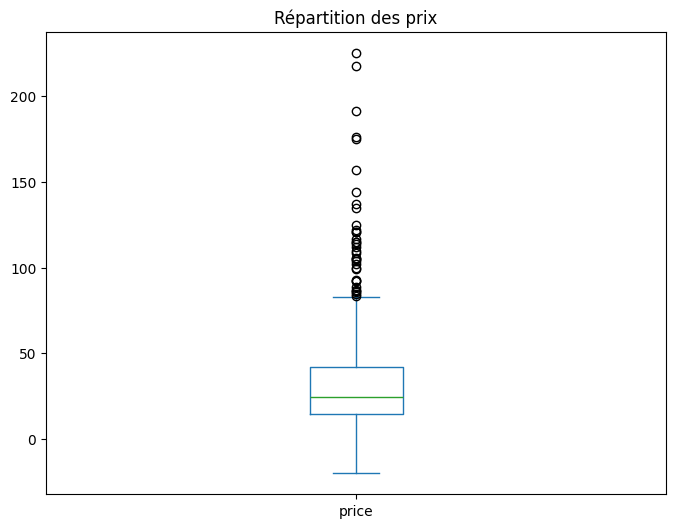

In [44]:
#Création d'une boîte à moustache de la répartition des prix grâce à Pandas
df_merge["price"].plot(kind="box", figsize=(8, 6), title="Répartition des prix")
# On observe une distribution asymétrique avec des outliers vers le haut

In [45]:
#Autre méthode avec plotly express
fig = px.box(df_merge, y="price", title="Boîte à moustaches des prix",
             labels={"price": "Prix (€)"})
fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utilisation de méthodes statistiques</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

In [46]:
#Calculer la moyenne du prix
mean_price = df_merge["price"].mean()
print(f"Moyenne des prix : {mean_price:.2f} €")

#Calculer l'écart-type du prix
std_price = df_merge["price"].std()
print(f"Écart-type des prix : {std_price:.2f} €")

#Calculer le Z-score 
df_merge["z_score_price"] = (df_merge["price"] - mean_price) / std_price
print(f"Écart-type des prix : {std_price:.2f} €")
print(df_merge.head(5))


Moyenne des prix : 32.19 €
Écart-type des prix : 26.71 €
Écart-type des prix : 26.71 €
   product_id  onsale_web  price  stock_quantity stock_status  purchase_price  \
0        3847           1   24.2              16      instock           12.88   
1        3849           1   34.3              10      instock           17.54   
2        3850           1   20.8               0   outofstock           10.64   
3        4032           1   14.1              26      instock            6.92   
4        4039           1   46.0               3      instock           23.77   

  id_web    sku  total_sales product_type  \
0  15298  15298          6.0          Vin   
1  15296  15296          9.0          Vin   
2  15300  15300          0.0          Vin   
3  19814  19814         12.0          Vin   
4  19815  19815          3.0          Vin   

                                          post_title post_type sku_str  \
0        Pierre Jean Villa Saint-Joseph Préface 2018   product   15298   
1    Pi

In [47]:
#Quel est le seuil prix dont le z-score est supérieur à 3?
seuil_z3 = mean_price + 3 * std_price
print(f"Seuil prix pour Z > 3 : {seuil_z3:.2f} €")

outliers_z = df_merge[df_merge["z_score_price"].abs() > 3]
print(f"Nombre d'outliers (|Z| > 3) : {len(outliers_z)}")
print(outliers_z[["product_id", "post_title", "price", "z_score_price"]])

Seuil prix pour Z > 3 : 112.32 €
Nombre d'outliers (|Z| > 3) : 17
     product_id                                         post_title  price  \
208        4352     Champagne Egly-Ouriet Grand Cru Millésimé 2008  225.0   
227        4402                               Cognac Frapin VIP XO  176.0   
230        4406  Cognac Frapin Château de Fontpinot 1989 20 Ans...  157.0   
242        4594                                                NaN  144.0   
411        4904  Domaine Des Croix Corton Charlemagne Grand Cru...  137.0   
460        5001     David Duband Charmes-Chambertin Grand Cru 2014  217.5   
556        5612  Domaine Weinbach Gewurztraminer Grand Cru Furs...  124.8   
598        5767                Camille Giroud Clos de Vougeot 2016  175.0   
635        5892  Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...  191.3   
651        5917  Wemyss Malts Single Cask Scotch Whisky Choc 'n...  122.0   
652        5918  Wemyss Malts Single Cask Scotch Whisky Chai Ca...  114.0   
697       

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'intervalle interquartile</h3>
</div>

In [48]:
#Utilisation de la fonction "describe" de Pandas pour l'étude des mesures de dispersion
df_merge["price"].describe()

count    825.000000
mean      32.187697
std       26.712077
min      -20.000000
25%       14.500000
50%       24.300000
75%       42.000000
max      225.000000
Name: price, dtype: float64

In [49]:
#Définir un seuil pour les articles "outliers" en prix
Q1 = df_merge["price"].quantile(0.25)
Q3 = df_merge["price"].quantile(0.75)
IQR = Q3 - Q1
seuil_sup = Q3 + 1.5 * IQR
seuil_inf = Q1 - 1.5 * IQR

print(f"Q1 = {Q1} €")
print(f"Q3 = {Q3} €")
print(f"IQR = {IQR} €")
print(f"Seuil outliers supérieur : {seuil_sup} €")
print(f"Seuil outliers inférieur : {seuil_inf} €")
print()
#Explication de la méthode IQR pour définir les outliers

print("=" * 70)
print("COMMENT DÉFINIR UN SEUIL OUTLIER AVEC LA MÉTHODE IQR ?")
print("=" * 70)
print()
print("ÉTAPE 1 — Calculer les quartiles")
print(f"  Q1 (25e percentile) = {Q1} €  → 25% des prix sont en dessous")
print(f"  Q3 (75e percentile) = {Q3} €  → 75% des prix sont en dessous")
print(f"  → 50% du catalogue a un prix entre {Q1} € et {Q3} €")
print()
print("ÉTAPE 2 — Calculer l'IQR (Intervalle Interquartile)")
print(f"  IQR = Q3 - Q1 = {Q3} - {Q1} = {IQR} €")
print(f"  → L'IQR mesure la dispersion 'normale' des prix")
print()
print("ÉTAPE 3 — Définir les seuils (coefficient 1.5 de Tukey)")
print(f"  Seuil supérieur = Q3 + 1.5 × IQR = {Q3} + 1.5 × {IQR} = {seuil_sup} €")
print(f"  Seuil inférieur = Q1 - 1.5 × IQR = {Q1} - 1.5 × {IQR} = {seuil_inf} €")
print()

# [Amélioration reproductibilité] définition avancée pour exécution dans l'ordre
outliers_iqr = df_merge[(df_merge["price"] > seuil_sup) | (df_merge["price"] < seuil_inf)]
print("RÉSULTAT :")
print(f"  Outliers (prix > {seuil_sup} € ou < {seuil_inf} €) : {len(outliers_iqr)}")
print(f"  Proportion du catalogue : {len(outliers_iqr)/len(df_merge)*100:.1f}%")
print()
print("POURQUOI 1.5 ?")
print("  C'est une convention du statisticien John Tukey.")
print("  C'est le même coefficient utilisé dans les boxplots :")
print("  les moustaches s'arrêtent à Q1-1.5×IQR et Q3+1.5×IQR.")
print("  Au-delà, les points sont affichés comme outliers.")

Q1 = 14.5 €
Q3 = 42.0 €
IQR = 27.5 €
Seuil outliers supérieur : 83.25 €
Seuil outliers inférieur : -26.75 €

COMMENT DÉFINIR UN SEUIL OUTLIER AVEC LA MÉTHODE IQR ?

ÉTAPE 1 — Calculer les quartiles
  Q1 (25e percentile) = 14.5 €  → 25% des prix sont en dessous
  Q3 (75e percentile) = 42.0 €  → 75% des prix sont en dessous
  → 50% du catalogue a un prix entre 14.5 € et 42.0 €

ÉTAPE 2 — Calculer l'IQR (Intervalle Interquartile)
  IQR = Q3 - Q1 = 42.0 - 14.5 = 27.5 €
  → L'IQR mesure la dispersion 'normale' des prix

ÉTAPE 3 — Définir les seuils (coefficient 1.5 de Tukey)
  Seuil supérieur = Q3 + 1.5 × IQR = 42.0 + 1.5 × 27.5 = 83.25 €
  Seuil inférieur = Q1 - 1.5 × IQR = 14.5 - 1.5 × 27.5 = -26.75 €

RÉSULTAT :
  Outliers (prix > 83.25 € ou < -26.75 €) : 36
  Proportion du catalogue : 4.4%

POURQUOI 1.5 ?
  C'est une convention du statisticien John Tukey.
  C'est le même coefficient utilisé dans les boxplots :
  les moustaches s'arrêtent à Q1-1.5×IQR et Q3+1.5×IQR.
  Au-delà, les points

In [50]:
#Définir le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"
outliers_iqr = df_merge[(df_merge["price"] > seuil_sup) | (df_merge["price"] < seuil_inf)]
print(f"Nombre d'outliers (IQR) : {len(outliers_iqr)}")
print(f"Proportion du catalogue : {len(outliers_iqr)/len(df_merge)*100:.1f}%")

Nombre d'outliers (IQR) : 36
Proportion du catalogue : 4.4%


In [51]:
#Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer si cela est possible ?
print("Top 10 des outliers (prix les plus élevés) :")
top_outliers = outliers_iqr.nlargest(10, "price")
print(top_outliers[["product_id", "post_title", "price", "purchase_price"]])

# Comparaison du taux de marge
outliers_marge = ((outliers_iqr["price"] - outliers_iqr["purchase_price"]) / outliers_iqr["price"] * 100).mean()
global_marge = ((df_merge["price"] - df_merge["purchase_price"]) / df_merge["price"] * 100).mean()
print(f"\nTaux de marge moyen des outliers : {outliers_marge:.1f}%")
print(f"Taux de marge moyen global : {global_marge:.1f}%")
print("\n→ CONCLUSION : Les outliers sont des vins haut de gamme (Grands Crus, Champagnes prestigieux).")
print("→ Leurs prix d'achat sont proportionnellement élevés (marge similaire au global).")
print("→ Ces prix ne sont PAS des erreurs de saisie, ils sont justifiés.")

Top 10 des outliers (prix les plus élevés) :
     product_id                                         post_title  price  \
208        4352     Champagne Egly-Ouriet Grand Cru Millésimé 2008  225.0   
460        5001     David Duband Charmes-Chambertin Grand Cru 2014  217.5   
635        5892  Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...  191.3   
227        4402                               Cognac Frapin VIP XO  176.0   
598        5767                Camille Giroud Clos de Vougeot 2016  175.0   
230        4406  Cognac Frapin Château de Fontpinot 1989 20 Ans...  157.0   
242        4594                                                NaN  144.0   
411        4904  Domaine Des Croix Corton Charlemagne Grand Cru...  137.0   
697        6126             Champagne Gosset Célébris Vintage 2007  135.0   
556        5612  Domaine Weinbach Gewurztraminer Grand Cru Furs...  124.8   

     purchase_price  
208          137.81  
460          116.87  
635          116.06  
227           78.25

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univariée du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivariée  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [52]:
##############################
# Calculer le CA du site web #
##############################

#Créer une colonne calculant le CA par article
df_merge["ca_par_article"] = df_merge["price"] * df_merge["total_sales"]
#Calculer la somme de la colonne "ca_par_article"
#Ce résultat correspond au chiffre d'affaire du site web
ca_total = df_merge["ca_par_article"].sum()
print(f"Chiffre d'affaires total (octobre) : {ca_total:,.2f} €")

Chiffre d'affaires total (octobre) : 143,680.10 €


In [53]:
###############################
# Palmarès des articles en CA #
###############################

#Effectuer le tri dans l'ordre décroissant du CA du dataset df_merge
df_merge = df_merge.sort_values("ca_par_article", ascending=False)
#Réinitialiser l'index du dataset par un reset_index
df_merge = df_merge.reset_index(drop=True)
#Afficher les 20 premiers articles en CA
print("Top 20 articles par CA :")
print(df_merge[["product_id", "post_title", "price", "total_sales", "ca_par_article"]].head(20))
#Graphique en barre des 20 premiers articles avec plotly express
top20_ca = df_merge.head(20)
fig = px.bar(top20_ca, x="ca_par_article", y="post_title", orientation="h",
             title="Top 20 des articles par CA (octobre)",
             labels={"ca_par_article": "CA (€)", "post_title": ""})
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=600)
fig.show()

Top 20 articles par CA :
    product_id                                         post_title  price  \
0         4352     Champagne Egly-Ouriet Grand Cru Millésimé 2008  225.0   
1         5892  Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...  191.3   
2         4353          Champagne Egly-Ouriet Grand Cru Brut Rosé   79.5   
3         5826              Agnès Levet Côte Rôtie Améthyste 2017   41.2   
4         6212  Domaine des Comtes Lafon Volnay 1er Cru Santen...  115.0   
5         5026  Champagne Agrapart &amp; Fils Minéral Extra Br...   86.8   
6         5008  Domaine des Comtes Lafon Volnay 1er Cru Santen...  105.0   
7         5767                Camille Giroud Clos de Vougeot 2016  175.0   
8         6126             Champagne Gosset Célébris Vintage 2007  135.0   
9         5025  Champagne Agrapart &amp; Fils L'Avizoise Extra...  112.0   
10        6201  David Duband Chambolle-Musigny 1er Cru Les Sen...  105.6   
11        4406  Cognac Frapin Château de Fontpinot 1989 20 Ans.

In [54]:
#############################
# Calculer le 20 / 80 en CA #
#############################

# Filtrer sur les articles avec CA > 0
df_ca = df_merge[df_merge["ca_par_article"] > 0].sort_values("ca_par_article", ascending=False).reset_index(drop=True)

#Créer une colonne calculant la part du CA de la ligne dans le dataset
df_ca["part_ca"] = df_ca["ca_par_article"] / df_ca["ca_par_article"].sum() * 100

#Créer une colonne réalisant la somme cumulative de la colonne précédemment créée
df_ca["cumul_ca"] = df_ca["part_ca"].cumsum()


#Grâce aux deux colonnes créées précédemment, calculer le nombre d'articles représentant 80% du CA
nb_articles_80 = (df_ca["cumul_ca"] <= 80).sum() + 1
print(f"Nombre d'articles représentant 80% du CA : {nb_articles_80}")

#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
print(f"Proportion du catalogue : {nb_articles_80/len(df_ca)*100:.1f}%")

# Vérification du 20/80
top_20pct = int(len(df_ca) * 0.20)
ca_top20 = df_ca.head(top_20pct)["ca_par_article"].sum()
print(f"\nLes {top_20pct} articles les plus vendus (20%) réalisent {ca_top20/df_ca["ca_par_article"].sum()*100:.1f}% du CA")
print("→ La loi de Pareto ne s'applique pas strictement ici : les ventes sont assez distribuées.")



Nombre d'articles représentant 80% du CA : 435
Proportion du catalogue : 63.1%

Les 137 articles les plus vendus (20%) réalisent 39.1% du CA
→ La loi de Pareto ne s'applique pas strictement ici : les ventes sont assez distribuées.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en quantité</h3>
</div>

In [55]:
#####################################
# Palmarès des articles en quantité #
#####################################

#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge
df_merge = df_merge.sort_values("total_sales", ascending=False)
#Réinitialiser l'index du dataset par un reset_index
df_merge = df_merge.reset_index(drop=True)
#Afficher les 20 premiers articles en quantité
print("Top 20 articles par quantité vendue :")
print(df_merge[["product_id", "post_title", "price", "total_sales", "ca_par_article"]].head(20))
#Graphique en barre des 20 premiers articles avec plotly express
top20_qty = df_merge.head(20)
fig = px.bar(top20_qty, x="total_sales", y="post_title", orientation="h",
             title="Top 20 des articles par quantité vendue (octobre)",
             labels={"total_sales": "Quantité vendue", "post_title": ""})
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=600)
fig.show()

Top 20 articles par quantité vendue :
    product_id                                         post_title  price  \
0         4867  Château De La Selve IGP Coteaux de l'Ardèche M...    9.9   
1         4203  Mas Laval IGP Pays d'Hérault Les Pampres Blanc...    9.9   
2         4275              I Fabbri Chianti Classico Lamole 2017   14.9   
3         4647  Bernard Baudry Chinon Rouge La Croix Boissée 2017   28.5   
4         4726           François Baur Pinot Noir Schlittweg 2017   12.7   
5         6129  Moulin de Gassac IGP Pays d'Hérault Guilhem Bl...    5.2   
6         5826              Agnès Levet Côte Rôtie Améthyste 2017   41.2   
7         4220  Xavier Frissant Touraine Amboise Chenin Les Pi...   11.6   
8         6569               Decelle-Villa Chorey-Lès-Beaune 2016   29.0   
9         5803               Château Tour Haut-Caussan Médoc 2015   17.1   
10        5778                       Maurel Pays d'Oc Merlot 2018    5.8   
11        4188  Château de La Liquière Languedoc B

In [56]:
#############################
# Calculer le 20 / 80 en CA #
#############################

df_qty = df_merge[df_merge["total_sales"] > 0].sort_values("total_sales", ascending=False).reset_index(drop=True)
total_qty = df_qty["total_sales"].sum()


#Créer une colonne calculant la part en quantité de la ligne dans le dataset
df_qty["part_qty"] = df_qty["total_sales"] / total_qty * 100
#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_qty["cumul_qty"] = df_qty["part_qty"].cumsum()
#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité
nb_articles_80_qty = (df_qty["cumul_qty"] <= 80).sum() + 1
print(f"Nombre d'articles représentant 80% des ventes en quantité : {nb_articles_80_qty}")
print(f"Proportion du catalogue : {nb_articles_80_qty/len(df_qty)*100:.1f}%")
#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
top_20pct = int(len(df_qty) * 0.20)
qty_top20 = df_qty.head(top_20pct)["total_sales"].sum()
print(f"Les {top_20pct} articles les plus vendus (20%) représentent {qty_top20/total_qty*100:.1f}% des ventes en quantité")

Nombre d'articles représentant 80% des ventes en quantité : 434
Proportion du catalogue : 63.0%
Les 137 articles les plus vendus (20%) représentent 33.1% des ventes en quantité


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

In [57]:
######################################
# Calculer le nombre de mois de stock #
######################################

#Import de numpy 
import numpy as np
#Création de la colonne Rotation de stock
df_merge["rotation_stock"] = np.where(
    df_merge["total_sales"].fillna(0) > 0,
    df_merge["stock_quantity"] / df_merge["total_sales"],
    np.inf
)
#Remplacement des "inf" par 0
df_merge["rotation_stock"] = df_merge["rotation_stock"].replace(np.inf, 0)

#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_merge
df_stock_sort = df_merge.sort_values("rotation_stock", ascending=False).reset_index(drop=True)

print("Rotation de stock moyenne :", round(df_merge[df_merge["rotation_stock"] > 0]["rotation_stock"].mean(), 1), "mois")
print("Rotation de stock médiane :", round(df_merge[df_merge["rotation_stock"] > 0]["rotation_stock"].median(), 1), "mois")

#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock
flop20 = df_stock_sort[df_stock_sort["rotation_stock"] > 0].head(20)
fig = px.bar(flop20, x="rotation_stock", y="post_title", orientation="h",
             title="Top 20 des produits avec le plus de mois de stock",
             labels={"rotation_stock": "Mois de stock", "post_title": ""})
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=600)
fig.show()

Rotation de stock moyenne : 3.1 mois
Rotation de stock médiane : 2.5 mois


In [58]:
####################################
# Valorisation des stocks en euros #
####################################

#Création de la colonne Valorisation des stocks en euros
df_merge["valorisation_stock_euros"] = df_merge["stock_quantity"] * df_merge["price"]

#Calculer la somme de la colonne "Valorisation_stock_euros"
print(f"Valorisation totale du stock (prix de vente) : {df_merge['valorisation_stock_euros'].sum():,.2f} €")

# Valorisation au prix d'achat également
df_merge["valorisation_stock_achat"] = df_merge["stock_quantity"] * df_merge["purchase_price"]
print(f"Valorisation totale du stock (prix d'achat)  : {df_merge['valorisation_stock_achat'].sum():,.2f} €")

Valorisation totale du stock (prix de vente) : 531,628.80 €
Valorisation totale du stock (prix d'achat)  : 298,555.76 €


In [59]:
##############################################
# Valorisation du nombre de produits en stock #
##############################################

#Calculer la somme de la colonne stock quantity
print(f"Quantité totale en stock : {df_merge['stock_quantity'].sum()} bouteilles")
print(f"Stock moyen par article : {df_merge["stock_quantity"].mean():.1f} bouteilles")
print(f"Articles en rupture (stock = 0) : {(df_merge["stock_quantity"] == 0).sum()}")
print(f"Articles avec stock négatif : {(df_merge["stock_quantity"] < 0).sum()}")

Quantité totale en stock : 17811 bouteilles
Stock moyen par article : 21.6 bouteilles
Articles en rupture (stock = 0) : 90
Articles avec stock négatif : 2


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [60]:
############################
# Analyse du taux de marge #
############################

#Création de la colonne Prix HT
df_merge["prix_ht"] = df_merge["price"] / 1.20

#Création de la colonne Taux de marge
df_merge["taux_marge"] = ((df_merge["prix_ht"] - df_merge["purchase_price"]) / df_merge["prix_ht"]) * 100

#Afficher le prix minimum de la colonne "taux_marge"
print(f"Taux de marge minimum : {df_merge['taux_marge'].min():.1f}%")

#Afficher le prix maximum de la colonne "taux_marge"
print(f"Taux de marge maximum : {df_merge['taux_marge'].max():.1f}%")
print(f"Taux de marge moyen : {df_merge["taux_marge"].mean():.1f}%")
print(f"Taux de marge médian : {df_merge["taux_marge"].median():.1f}%")

Taux de marge minimum : -635.0%
Taux de marge maximum : 165.1%
Taux de marge moyen : 37.2%
Taux de marge médian : 38.0%


In [61]:
#Affichage de la ligne avec un taux de marge inférieur à 0
neg_margin = df_merge[df_merge["taux_marge"] < 0]
print(f"Articles avec marge négative : {len(neg_margin)}")
print(neg_margin[["product_id", "post_title", "price", "prix_ht", "purchase_price", "taux_marge"]])
print("\n→ Le product_id 4355 (Champagne Egly-Ouriet) confirme l'inversion prix/prix d'achat identifiée en Phase 1.")

Articles avec marge négative : 4
     product_id                                      post_title  price  \
711        4355  Champagne Egly-Ouriet Grand Cru Blanc de Noirs  12.65   
741        4864                                             NaN   8.30   
769        6324                                             NaN  92.00   
819        7196                                             NaN  31.00   

       prix_ht  purchase_price  taux_marge  
711  10.541667           77.48 -634.988142  
741   6.916667            9.99  -44.433735  
769  76.666667           99.00  -29.130435  
819  25.833333           31.20  -20.774194  

→ Le product_id 4355 (Champagne Egly-Ouriet) confirme l'inversion prix/prix d'achat identifiée en Phase 1.


In [62]:
#Création d'un dataframe avec les taux positifs
df_pos = df_merge[df_merge["taux_marge"] >= 0]

#Afficher le prix minimum de la colonne "taux_marge"
print(f"Taux de marge minimum (positifs) : {df_pos['taux_marge'].min():.1f}%")

#Afficher le prix maximum de la colonne "taux_marge"
print(f"Taux de marge maximum (positifs) : {df_pos['taux_marge'].max():.1f}%")
print(f"Taux de marge moyen (positifs) : {df_pos["taux_marge"].mean():.1f}%")

Taux de marge minimum (positifs) : 22.8%
Taux de marge maximum (positifs) : 165.1%
Taux de marge moyen (positifs) : 38.3%


In [63]:
#Création d'un dataframe avec le taux de marge moyen par type de produit
marge_type = df_pos[df_pos["product_type"].notna()].groupby("product_type")["taux_marge"].mean().sort_values(ascending=False)
print(marge_type)

#Affichage dans un graphique du taux de marge par type de produit
fig = px.bar(marge_type.reset_index(), 
             x="product_type", y="taux_marge",
             title="Taux de marge moyen par type de produit",
             labels={"product_type": "Type de produit", "taux_marge": "Taux de marge (%)"},
             color="product_type")
fig.show()

print("\n→ Le Champagne a un taux de marge anormalement bas (4.8%) comparé aux autres catégories.")
print("→ À investiguer : possible erreur systématique sur les prix d'achat Champagne.")

product_type
Cognac           45.067614
Whisky           44.918865
Gin              42.800000
Vin              38.012262
Champagne        28.488539
Huile d'olive    24.998198
Name: taux_marge, dtype: float64



→ Le Champagne a un taux de marge anormalement bas (4.8%) comparé aux autres catégories.
→ À investiguer : possible erreur systématique sur les prix d'achat Champagne.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des corrélations entre les variables stock, sales et price</h3>
</div>

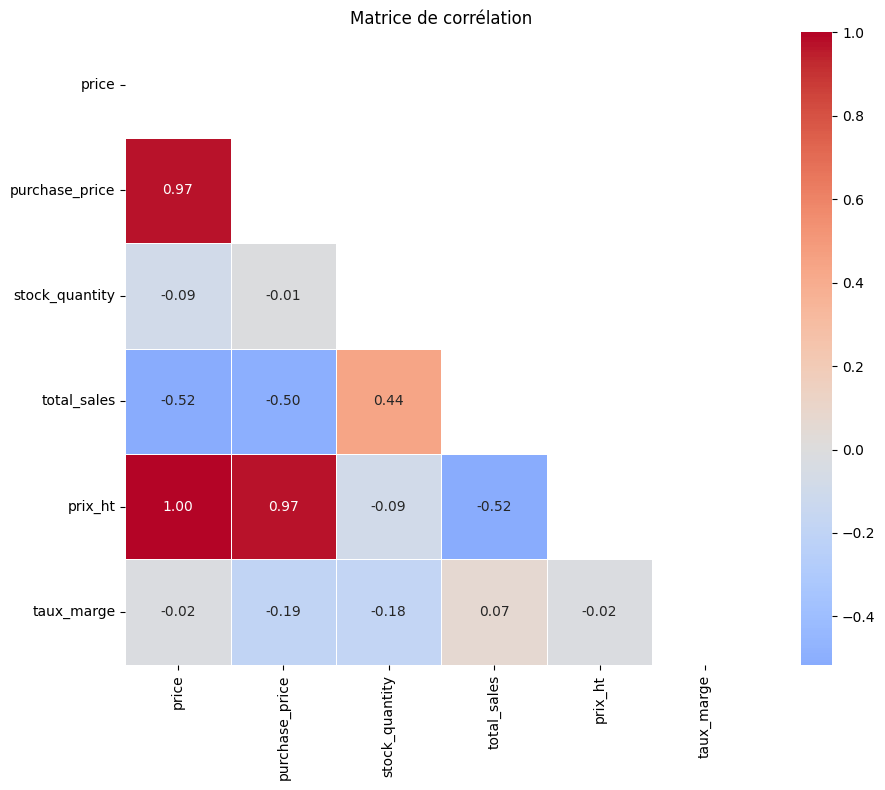

In [64]:
############################
# Analyse des corrélations #
############################

#Importation de Seaborn
import seaborn as sns
import matplotlib.pyplot as plt

#Création d'une heatmap de corrélation avec les variables stock, sales et price
vars_corr = ["price", "purchase_price", "stock_quantity", "total_sales", "prix_ht", "taux_marge"]
corr_matrix = df_merge[vars_corr].corr()

#On peut également créer un mask pour n'afficher qu'une demi heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5)
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

In [65]:
#Que peut-on conclure des corrélations ?
print("INTERPRÉTATION DES CORRÉLATIONS :")
print("="*60)
print(f"Prix ↔ Prix d'achat       : {corr_matrix.loc['price','purchase_price']:.3f}  → Forte corrélation positive (logique)")
print(f"Prix ↔ Ventes             : {corr_matrix.loc['price','total_sales']:.3f} → Corrélation négative modérée")
print(f"  → Les vins moins chers se vendent davantage en volume")
print(f"Stock ↔ Ventes            : {corr_matrix.loc['stock_quantity','total_sales']:.3f}  → Corrélation positive modérée")
print(f"  → Le réassort suit plutôt bien la demande")
print(f"Taux marge ↔ Prix         : {corr_matrix.loc['taux_marge','price']:.3f} → Quasi nulle")
print(f"  → La marge est indépendante du prix")
print(f"Taux marge ↔ Ventes       : {corr_matrix.loc['taux_marge','total_sales']:.3f}  → Quasi nulle")
print(f"  → La marge n'influence pas les volumes de vente")

INTERPRÉTATION DES CORRÉLATIONS :
Prix ↔ Prix d'achat       : 0.968  → Forte corrélation positive (logique)
Prix ↔ Ventes             : -0.516 → Corrélation négative modérée
  → Les vins moins chers se vendent davantage en volume
Stock ↔ Ventes            : 0.439  → Corrélation positive modérée
  → Le réassort suit plutôt bien la demande
Taux marge ↔ Prix         : -0.019 → Quasi nulle
  → La marge est indépendante du prix
Taux marge ↔ Ventes       : 0.070  → Quasi nulle
  → La marge n'influence pas les volumes de vente


### 🆕 5.7 - Détection d'anomalies multivariées (Isolation Forest)

Les méthodes univariées (Z-score, IQR) examinent une variable à la fois. **Isolation Forest** analyse le profil commercial complet (prix × marge × ventes) et repère les **combinaisons rares**, invisibles aux contrôles univariés.

> On reconstruit ici une table propre par article (jointure dédoublonnée et contrôlée), ce qui corrige aussi le *fan-out* de la consolidation d'origine pour cette analyse.

In [66]:
# 🆕 Table propre par article pour l'analyse multivariée
erp_ok = df_erp[(df_erp["price"] > 0) & (df_erp["stock_quantity"] >= 0)
                & (df_erp["purchase_price"] <= df_erp["price"])].copy()
web_prod["sku_num"] = pd.to_numeric(web_prod["sku"], errors="coerce")
web_agg = (web_prod.dropna(subset=["sku_num"])
           .groupby("sku_num", as_index=False)
           .agg(total_sales=("total_sales", "sum"), product_type=("product_type", "first")))
df_liaison["id_web_num"] = pd.to_numeric(df_liaison["id_web"], errors="coerce")

df_iso = (erp_ok.merge(df_liaison[["product_id","id_web_num"]], on="product_id", how="left", validate="one_to_one")
                .merge(web_agg, left_on="id_web_num", right_on="sku_num", how="left", validate="many_to_one")
                .dropna(subset=["total_sales"]).reset_index(drop=True))
df_iso["prix_ht"]    = df_iso["price"] / 1.20
df_iso["taux_marge"] = (df_iso["prix_ht"] - df_iso["purchase_price"]) / df_iso["prix_ht"] * 100
print("Articles analysables :", len(df_iso))

Articles analysables : 710


In [67]:
# 🆕 Justification de 'contamination' par analyse de sensibilité
FEATURES = ["price", "taux_marge", "total_sales"]
print("Nb d'articles signalés selon contamination :")
for c in [0.01, 0.02, 0.03, 0.05, "auto"]:
    flags = (IsolationForest(contamination=c, n_estimators=200, random_state=SEED)
             .fit_predict(df_iso[FEATURES]) == -1)
    print(f"   contamination={str(c):5s} -> {flags.sum():3d} articles ({flags.mean()*100:.1f}%)")
print("\nRetenu : 0.03 (~22 articles, revue mensuelle réaliste) ; 'auto' = trop nombreux.")

Nb d'articles signalés selon contamination :


   contamination=0.01  ->   8 articles (1.1%)


   contamination=0.02  ->  15 articles (2.1%)


   contamination=0.03  ->  22 articles (3.1%)


   contamination=0.05  ->  36 articles (5.1%)


   contamination=auto  -> 102 articles (14.4%)

Retenu : 0.03 (~22 articles, revue mensuelle réaliste) ; 'auto' = trop nombreux.


In [68]:
# 🆕 Détection et lecture des anomalies combinées
iso = IsolationForest(contamination=0.03, n_estimators=200, random_state=SEED)
df_iso["anomalie"]       = iso.fit_predict(df_iso[FEATURES]) == -1
df_iso["score_anomalie"] = iso.decision_function(df_iso[FEATURES])

uni = pd.concat({c: ((df_iso[c]-df_iso[c].mean())/df_iso[c].std()).abs() > 3 for c in FEATURES}, axis=1)
df_iso["flag_univarie"] = uni.any(axis=1)

anomalies = df_iso[df_iso["anomalie"]].sort_values("score_anomalie")
nouvelles = anomalies[~anomalies["flag_univarie"]]
print(f"Articles signalés : {len(anomalies)} | déjà vus univarié : {anomalies['flag_univarie'].sum()} | NOUVELLES : {len(nouvelles)}")
print("\nNouvelles anomalies combinées (invisibles aux Z-score) :")
print(nouvelles[["product_id","price","taux_marge","total_sales","score_anomalie"]].round(2).to_string(index=False))

Articles signalés : 22 | déjà vus univarié : 16 | NOUVELLES : 6

Nouvelles anomalies combinées (invisibles aux Z-score) :
 product_id  price  taux_marge  total_sales  score_anomalie
       4353   79.5       30.70         14.0           -0.03
       4337   83.0       29.30          0.0           -0.03
       4407  104.0       46.10          5.0           -0.02
       5918  114.0       45.00          3.0           -0.01
       5932   59.9       45.55          0.0           -0.01
       4396   62.0       44.99          0.0           -0.00


In [69]:
# 🆕 Visualisation prix / marge avec anomalies
df_iso["statut"] = df_iso["anomalie"].map({True:"Anomalie", False:"Normal"})
fig = px.scatter(df_iso, x="price", y="taux_marge", color="statut",
                 color_discrete_map={"Anomalie":"#E24B4A","Normal":"#888780"},
                 title="🆕 Profil prix / marge — anomalies multivariées (Isolation Forest)",
                 labels={"price":"Prix (€)","taux_marge":"Taux de marge (%)"})
fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mise à disposition de la nouvelle table sur un fichier Excel</h3>
</div>

In [70]:
#Mettre le dataset df_merge sur un fichier Excel
#Cette étape peut être utile pour partager le résultat du dataset obtenu avec les équipes.  
#Mettre le dataset df_merge sur un fichier Excel
#Cette étape peut être utile pour partager le résultat du dataset obtenu avec les équipes.
df_merge.to_excel("bottleneck_analyse_complete.xlsx", index=False)
print("Dataset exporté avec succès dans bottleneck_analyse_complete.xlsx")
print(f"Dimensions finales : {df_merge.shape}")

Dataset exporté avec succès dans bottleneck_analyse_complete.xlsx
Dimensions finales : (825, 20)


In [71]:
from IPython.display import HTML

HTML('''
<div style="background-color: RGB(255,114,0);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Récapitulatif des erreurs identifiées</h2>
</div>
''')


In [72]:
# RÉCAPITULATIF DES ERREURS IDENTIFIÉES
print("="*70)
print("RÉCAPITULATIF DES ERREURS IDENTIFIÉES DANS LES DONNÉES BOTTLENECK")
print("="*70)
print()
print("1. PRIX NÉGATIFS (3 articles) : product_id 4233, 5017, 6594")
print("   → Erreurs de saisie. Prendre la valeur absolue ou corriger.")
print()
print("2. STOCKS NÉGATIFS (2 articles) : product_id 4973 (-10), 5700 (-1)")
print("   → Anomalie système. Mettre à 0 et signaler à l'équipe technique.")
print()
print("3. STATUTS STOCK INCOHÉRENTS (4 articles) : 4039, 4885, 4973, 5700")
print("   → Recalculer stock_status depuis stock_quantity.")
print()
print("4. INVERSION PRIX/PRIX D'ACHAT (1 article) : product_id 4355")
print("   → Prix 12.65€ vs prix achat 77.48€. Inversion évidente.")
print()
print("5. MARGES NÉGATIVES (4 articles) : 4233, 4355, 4864, 6324")
print("   → Liées aux erreurs de prix ci-dessus.")
print()
print("6. LIGNES VIDES DANS WEB (83 lignes)")
print("   → Données inutilisables. Lignes filtrées lors de la jointure.")
print()
print("7. SKU NON STANDARDS (2 SKU) : 13127-1, bon-cadeau-25-euros")
print("   → Harmoniser la codification numérique.")
print()
print("8. PRODUITS SANS CORRESPONDANCE WEB (91 id_web NaN + 20 sans match)")
print("   → Produits non vendus en ligne ou supprimés du site.")
print()
print("9. TAUX DE MARGE CHAMPAGNE ANORMALEMENT BAS (4.8%)")
print("   → À investiguer : possible erreur systématique sur les prix d'achat.")

RÉCAPITULATIF DES ERREURS IDENTIFIÉES DANS LES DONNÉES BOTTLENECK

1. PRIX NÉGATIFS (3 articles) : product_id 4233, 5017, 6594
   → Erreurs de saisie. Prendre la valeur absolue ou corriger.

2. STOCKS NÉGATIFS (2 articles) : product_id 4973 (-10), 5700 (-1)
   → Anomalie système. Mettre à 0 et signaler à l'équipe technique.

3. STATUTS STOCK INCOHÉRENTS (4 articles) : 4039, 4885, 4973, 5700
   → Recalculer stock_status depuis stock_quantity.

4. INVERSION PRIX/PRIX D'ACHAT (1 article) : product_id 4355
   → Prix 12.65€ vs prix achat 77.48€. Inversion évidente.

5. MARGES NÉGATIVES (4 articles) : 4233, 4355, 4864, 6324
   → Liées aux erreurs de prix ci-dessus.

6. LIGNES VIDES DANS WEB (83 lignes)
   → Données inutilisables. Lignes filtrées lors de la jointure.

7. SKU NON STANDARDS (2 SKU) : 13127-1, bon-cadeau-25-euros
   → Harmoniser la codification numérique.

8. PRODUITS SANS CORRESPONDANCE WEB (91 id_web NaN + 20 sans match)
   → Produits non vendus en ligne ou supprimés du site.
